# Data Collection Pipeline — CC-NEWS

**Project:** SPZ — Geographic Bias in Pre-Trained Sentiment Classifiers

**Author:** Rezvaneh Mousavi | JLU Giessen | M.Sc. Data Analytics

**Supervisor:** Prof. Dr. Stefan Hennemann

---

**Purpose of this notebook:**

This notebook collects English-language news articles from the Common Crawl News (CC-NEWS) archive, extracts lead paragraphs, and assigns an initial country-of-publication label based on the article's source domain. This constitutes the first of three independent geographic assignment methods used in this study (URL-based, NER-based, and manual annotation).

**Pipeline overview:**

1. Download WARC archive files from CC-NEWS to temporary storage
2. Extract article text from raw HTML using trafilatura
3. Filter for English-language articles and remove non-news domains
4. Extract lead paragraphs for sentiment analysis
5. Assign country of publication based on a curated domain-to-country mapping
6. Save results to Google Drive

**Data persistence:** Each processing stage saves its output to Google Drive. If the Colab session expires, re-running a cell will load the existing output rather than reprocessing from scratch.

**WARC file selection:** To maximise geographic diversity, WARC files are selected randomly from the monthly listing (with a fixed seed for reproducibility) rather than sequentially. Sequential files capture the same crawl window and tend to over-represent the same set of websites.

**File versioning:** Output filenames include a version tag (e.g. `_v2`). When parameters change (more WARC files, updated domain mapping), the version is incremented. Previous versions remain on Drive as a record of earlier pipeline runs.

---
## 0. Setup and Configuration

In [1]:
# Install required packages:
# warcio       - reads WARC (Web ARChive) files record by record
# trafilatura  - extracts main article text from raw HTML, removing navigation, ads, footers
# langdetect   - statistical language identification
# tldextract   - decomposes URLs into subdomain, domain, and suffix components
#                e.g. "www.bbc.co.uk" -> subdomain="www", domain="bbc", suffix="co.uk"

!pip install -q warcio trafilatura langdetect tldextract

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.8 MB/s eta 0:00:00


In [2]:
import os
import re
import gzip
import random
import requests
import pandas as pd
from io import BytesIO
from warcio.archiveiterator import ArchiveIterator
from trafilatura import extract
from langdetect import detect, LangDetectException, DetectorFactory
import tldextract
from datetime import datetime

# Fix seed for reproducible language detection results
DetectorFactory.seed = 0

print('All imports loaded successfully.')

All imports loaded successfully.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# --- Path configuration ---
# This path assumes you have added a shortcut to the "UNI" folder in My Drive.
# To do this: Google Drive > Shared with me > right-click UNI > Organise > Add shortcut to Drive > My Drive
#
# If your folder structure differs, adjust DRIVE_BASE accordingly.

DRIVE_BASE = '/content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule'
DATA_RAW = f'{DRIVE_BASE}/data/raw'
DATA_PROCESSED = f'{DRIVE_BASE}/data/processed'

for folder in [DATA_RAW, DATA_PROCESSED]:
    os.makedirs(folder, exist_ok=True)

assert os.path.exists(DRIVE_BASE), f'Path not found: {DRIVE_BASE} -- check your Drive shortcut.'
print(f'Working directory: {DRIVE_BASE}')
print(f'Data (raw):       {DATA_RAW}')
print(f'Data (processed): {DATA_PROCESSED}')

Working directory: /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule
Data (raw):       /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/raw
Data (processed): /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed


In [5]:
# --- Collection parameters ---

TARGET_YEAR = '2025'
MONTHS = [f'{m:02d}' for m in range(1, 13)]   # '01' through '12'
WARCS_PER_MONTH = 1                           # 1 random WARC per month → 12 files total
MIN_ARTICLE_LENGTH = 200                      # Minimum character count to consider a valid article
RANDOM_SEED = 42                              # For reproducible random WARC file selection

# Version tag for output filenames. Previous versions remain on Drive untouched.
# v1 = initial run (3 sequential WARCs, base domain mapping)
# v2 = 5 random WARCs from 2025/01 only, expanded domain mapping (22 countries), lead extraction
# v3 = 12 WARCs (1 random per month of 2025), post-Hennemann redesign (Apr 17 meeting)
DATA_VERSION = 'v3'


---
## 1. Retrieve WARC File Listing (Multi-Month Sampling)

CC-NEWS organises its archive by month. Each month has a listing file (`warc.paths.gz`) with all WARC files for that month.

For v3 we fetch the listing for every month of 2025 and randomly select `WARCS_PER_MONTH` file(s) from each. This gives temporally balanced coverage across the year (12 WARCs total, one per month), replacing v2's single-month approach.


In [6]:
# Fetch WARC listings month by month, pick WARCS_PER_MONTH at random from each.
# random.seed() is called ONCE before the loop — the draws stay reproducible as
# long as MONTHS iteration order is unchanged.

random.seed(RANDOM_SEED)
selected_warc_paths = []

print(f'Selecting {WARCS_PER_MONTH} WARC(s) per month from {TARGET_YEAR} '
      f'(seed={RANDOM_SEED}):\n')

for month in MONTHS:
    listing_url = f'https://data.commoncrawl.org/crawl-data/CC-NEWS/{TARGET_YEAR}/{month}/warc.paths.gz'
    response = requests.get(listing_url)
    response.raise_for_status()

    month_paths = gzip.decompress(response.content).decode('utf-8').strip().split('\n')
    picks = random.sample(month_paths, WARCS_PER_MONTH)
    selected_warc_paths.extend(picks)

    for p in picks:
        print(f'  {TARGET_YEAR}-{month}: {len(month_paths):>4} files available → picked {p.split("/")[-1]}')

print(f'\nTotal WARCs selected: {len(selected_warc_paths)}')


Selecting 1 WARC(s) per month from 2025 (seed=42):

  2025-01:  403 files available → picked CC-NEWS-20250126060038-00483.warc.gz
  2025-02:  386 files available → picked CC-NEWS-20250205164804-00616.warc.gz
  2025-03:  462 files available → picked CC-NEWS-20250301204804-00957.warc.gz
  2025-04:  491 files available → picked CC-NEWS-20250424075313-01786.warc.gz
  2025-05:  479 files available → picked CC-NEWS-20250509123015-02038.warc.gz
  2025-06:  437 files available → picked CC-NEWS-20250609141244-02502.warc.gz
  2025-07:  493 files available → picked CC-NEWS-20250708052153-02928.warc.gz
  2025-08:  495 files available → picked CC-NEWS-20250805120403-03378.warc.gz
  2025-09:  556 files available → picked CC-NEWS-20250906164159-03906.warc.gz
  2025-10:  596 files available → picked CC-NEWS-20251030102726-04916.warc.gz
  2025-11:  574 files available → picked CC-NEWS-20251105095620-05043.warc.gz
  2025-12:  616 files available → picked CC-NEWS-20251231073821-06132.warc.gz

Total WARCs

---
## 2. Pipeline Functions

The following cells define the core processing functions. They are executed in Section 3.

### 2.1 WARC Download and Article Extraction

A WARC file contains sequential records, each representing one HTTP transaction captured by the crawler. We filter for `response` records with HTML content, then use `trafilatura` to extract the main article body. Trafilatura is designed specifically for news and web content extraction: it identifies the primary content area and strips navigation elements, advertisements, and boilerplate.

In [7]:
def download_warc(warc_path):
    """Download a WARC file from Common Crawl into memory."""
    url = f'https://data.commoncrawl.org/{warc_path}'
    filename = warc_path.split('/')[-1]
    print(f'  Downloading {filename}...')
    response = requests.get(url, stream=True)
    response.raise_for_status()
    size_mb = len(response.content) / (1024 * 1024)
    print(f'  Size: {size_mb:.1f} MB')
    return BytesIO(response.content)

In [8]:
def extract_articles_from_warc(warc_stream, min_length=MIN_ARTICLE_LENGTH):
    """
    Extract article text, URL, and capture date from a WARC file.

    Processing logic:
    - Only HTTP response records are considered (not requests or metadata).
    - Only text/html content types are processed (images, PDFs, etc. are skipped).
    - trafilatura handles the HTML-to-text conversion.
    - Articles shorter than min_length characters are discarded, as these are
      typically navigation pages, error pages, or incomplete extractions.
    """
    articles = []
    skipped_non_html = 0
    skipped_short = 0
    errors = 0

    for record in ArchiveIterator(warc_stream):
        if record.rec_type != 'response':
            continue

        content_type = record.http_headers.get_header('Content-Type') or ''
        if 'text/html' not in content_type:
            skipped_non_html += 1
            continue

        try:
            url = record.rec_headers.get_header('WARC-Target-URI')
            date = record.rec_headers.get_header('WARC-Date')
            html = record.content_stream().read().decode('utf-8', errors='replace')
            text = extract(html)

            if text and len(text) >= min_length:
                articles.append({'url': url, 'date': date, 'text': text})
            else:
                skipped_short += 1
        except Exception:
            errors += 1
            continue

    print(f'  Extracted: {len(articles)} articles '
          f'| {skipped_non_html} non-HTML | {skipped_short} too short | {errors} errors')
    return articles

### 2.2 Language Detection and Domain Filtering

Two-stage filtering is applied:

1. **Language detection** via `langdetect`, applied to the first 500 characters of each article. This is sufficient for reliable identification and avoids unnecessary computation on full texts.

2. **Domain blacklist** to remove non-news domains (social media, aggregators, e-commerce) that pass the language filter. The previous semester project (Mousavi & Brandao da Silva, 2025) found that language detection alone was insufficient for clean filtering — non-news English-language pages (e.g. Reddit posts, Wikipedia articles, e-commerce listings) passed the language filter but were not valid news articles. In that project, URL path pattern matching served as an implicit whitelist. Here, because the collection scope is broader (all English news, not category-specific), an explicit domain blacklist is used instead. The specific blacklist below was constructed for this study.

In [9]:
def detect_language(text):
    """Return ISO 639-1 language code, or None if detection fails."""
    try:
        return detect(text[:500])
    except LangDetectException:
        return None

In [10]:
DOMAIN_BLACKLIST = {
    # Social media and user-generated content
    'reddit.com', 'twitter.com', 'x.com', 'facebook.com',
    'youtube.com', 'instagram.com', 'tiktok.com',
    # News aggregators and portals
    'news.google.com', 'news.yahoo.com', 'msn.com',
    'flipboard.com', 'apple.news',
    # Weather and utilities
    'weather.com', 'accuweather.com',
    # Non-news
    'wikipedia.org', 'amazon.com', 'ebay.com',
    'pinterest.com', 'linkedin.com',
}


def is_blacklisted(url):
    """Check whether a URL belongs to a blacklisted domain."""
    try:
        ext = tldextract.extract(url)
        return ext.registered_domain in DOMAIN_BLACKLIST
    except Exception:
        return True  # reject unparseable URLs

### 2.3 Lead Paragraph Extraction

In news writing, the lead (first 1–2 paragraphs) carries the core information and the article's primary stance. Sentiment classifiers are applied to the lead rather than the full article because:

1. Leads are concise and carry a clear sentiment signal, whereas full articles contain mixed sentiment that dilutes the measurement.
2. This approach was validated in the previous semester project and recommended by Prof. Hennemann.

Both the full text and the extracted lead are retained in the dataset.

*(Adapted from Liubov Brandao da Silva's pipeline, previous semester project.)*

In [11]:
def split_paragraphs(text):
    """
    Split article text into paragraphs.

    Tries three strategies in order:
    1. Split on double newlines (standard paragraph separator)
    2. Split on single newlines (some sources use single breaks)
    3. Group sentences into blocks of 3 (fallback for unstructured text)
    """
    text = re.sub(r'\n{3,}', '\n\n', text)
    paras = [p.strip() for p in text.split('\n\n') if p.strip()]

    if len(paras) <= 1:
        paras = [p.strip() for p in text.split('\n') if p.strip()]

    if len(paras) <= 1:
        sentences = re.split(r'(?<=[.!?])\s+', text)
        paras = [' '.join(sentences[i:i+3]) for i in range(0, len(sentences), 3)]

    return paras


def extract_lead(text):
    """
    Extract the lead paragraph from a news article.

    If the first paragraph is very short (< 180 characters), it is combined
    with the second paragraph. This handles cases where the dateline, byline,
    or a brief subheading is treated as a separate paragraph by the extractor.

    Returns:
        (lead_text, lead_status)
        lead_status is one of:
        - 'ok': valid lead extracted
        - 'flagged': lead is short but usable (< 120 chars)
        - 'rejected': no usable lead could be extracted
    """
    paragraphs = split_paragraphs(text)

    if not paragraphs:
        return None, 'rejected'

    lead = paragraphs[0]

    # Combine with second paragraph if first is very short
    if len(lead) < 180 and len(paragraphs) > 1:
        lead = lead + ' ' + paragraphs[1]

    if len(lead) < 120:
        return lead, 'flagged'

    # Cap length to avoid overly long leads
    if len(lead) > 1200:
        lead = lead[:1200]

    return lead, 'ok'

### 2.4 URL-Based Country Assignment (Method 1 of 3)

This is the first and simplest of the three geographic assignment methods used in this study. It maps each article's source domain to a country of publication using a curated lookup table.

**What it captures:** Where the article was *published* (i.e., the news organisation's country of origin).

**What it does not capture:** What country the article is *about*. For example, a BBC article reporting on Indian elections would be labelled UK by this method. The NER + Geonames approach (Method 2, Notebook 02) addresses this distinction.

**Limitations:**
- Only works for domains explicitly listed in the mapping.
- Articles from unlisted domains are marked as unassigned, not discarded.

**Country selection approach:** Rather than restricting to five pre-specified regions, all identifiable news domains are assigned a country code using ISO 3166-1 alpha-2 codes. Countries with insufficient article counts are excluded at the analysis stage. This data-driven approach avoids selection bias and allows unexpected patterns to emerge.

**Mapping construction:** The initial mapping covered ~40 domains across 5 target countries (US, UK, AU, IN, DE). After the first pipeline run, the top 100 unassigned domains were analysed and classified, expanding coverage from 8% to 60% of English-language articles and adding 17 additional countries. Aggregator platforms (Yahoo, Substack), non-news sites, and press release wires were excluded.

In [12]:
DOMAIN_TO_COUNTRY = {
    # === United States ===
    # Major national outlets
    'nytimes.com': 'US',
    'washingtonpost.com': 'US',
    'apnews.com': 'US',
    'foxnews.com': 'US',
    'cnn.com': 'US',
    'usatoday.com': 'US',
    'latimes.com': 'US',
    'nbcnews.com': 'US',
    'cbsnews.com': 'US',
    'npr.org': 'US',
    'politico.com': 'US',
    'thehill.com': 'US',
    'reuters.com': 'US',
    'bloomberg.com': 'US',
    'realclearpolitics.com': 'US',
    'fastcompany.com': 'US',
    'newsday.com': 'US',
    # Financial / sports
    'etfdailynews.com': 'US',
    'cbssports.com': 'US',
    'rotowire.com': 'US',
    'wkrb13.com': 'US',
    'si.com': 'US',
    'tickerreport.com': 'US',
    'sportingnews.com': 'US',
    'oursportscentral.com': 'US',
    'clutchpoints.com': 'US',
    'nhl.com': 'US',
    'rivals.com': 'US',
    'comicbook.com': 'US',
    # Military / government
    'dvidshub.net': 'US',
    # Local TV stations
    'nbcsandiego.com': 'US',
    'newson6.com': 'US',
    'kstp.com': 'US',
    'krgv.com': 'US',
    'kvia.com': 'US',
    'kesq.com': 'US',
    'kyma.com': 'US',
    'localnews8.com': 'US',
    'wbrz.com': 'US',
    'whec.com': 'US',
    'keyt.com': 'US',
    # Public radio
    'delmarvapublicmedia.org': 'US',
    'kyuk.org': 'US',
    'wrkf.org': 'US',
    'wlrn.org': 'US',
    'knau.org': 'US',
    'cfpublic.org': 'US',
    'kunr.org': 'US',
    'tpr.org': 'US',
    'aspenpublicradio.org': 'US',
    'kunm.org': 'US',
    'wrvo.org': 'US',
    'kbbi.org': 'US',
    'wyomingpublicmedia.org': 'US',
    'ketr.org': 'US',
    'wuwf.org': 'US',
    'kuaf.com': 'US',
    'kclu.org': 'US',
    'kawc.org': 'US',
    'ctpublic.org': 'US',
    'ksut.org': 'US',
    'delawarepublic.org': 'US',
    'nhpr.org': 'US',
    'wvpe.org': 'US',
    'boisestatepublicradio.org': 'US',
    'upr.org': 'US',
    'kvcrnews.org': 'US',
    'wwno.org': 'US',
    'whqr.org': 'US',
    # Regional newspapers
    'spokesman.com': 'US',
    'pressherald.com': 'US',
    'staradvertiser.com': 'US',
    'mymotherlode.com': 'US',

    # === United Kingdom ===
    'bbc.co.uk': 'UK',
    'bbc.com': 'UK',
    'theguardian.com': 'UK',
    'telegraph.co.uk': 'UK',
    'independent.co.uk': 'UK',
    'dailymail.co.uk': 'UK',
    'mirror.co.uk': 'UK',
    'thetimes.co.uk': 'UK',
    'sky.com': 'UK',
    'tribalfootball.com': 'UK',
    'techbullion.com': 'UK',

    # === Australia ===
    'abc.net.au': 'AU',
    'smh.com.au': 'AU',
    'news.com.au': 'AU',
    'theaustralian.com.au': 'AU',
    'sbs.com.au': 'AU',
    '9news.com.au': 'AU',
    'thewest.com.au': 'AU',
    'perthnow.com.au': 'AU',

    # === India ===
    'thehindu.com': 'IN',
    'ndtv.com': 'IN',
    'hindustantimes.com': 'IN',
    'indianexpress.com': 'IN',
    'firstpost.com': 'IN',
    'theprint.in': 'IN',
    'scroll.in': 'IN',
    'livemint.com': 'IN',
    'deccanherald.com': 'IN',
    'business-standard.com': 'IN',
    'thehawk.in': 'IN',
    'latestly.com': 'IN',
    'lokmattimes.com': 'IN',
    'indiatimes.com': 'IN',
    'timesnownews.com': 'IN',
    'newindianexpress.com': 'IN',
    'republicworld.com': 'IN',
    'newsdrum.in': 'IN',
    'thehansindia.com': 'IN',
    'telegraphindia.com': 'IN',
    'sakshipost.com': 'IN',
    'etvbharat.com': 'IN',
    'millenniumpost.in': 'IN',
    'indiatvnews.com': 'IN',
    'newsbytesapp.com': 'IN',
    'india.com': 'IN',
    'thestatesman.com': 'IN',
    'dtnext.in': 'IN',
    'wionews.com': 'IN',
    'mid-day.com': 'IN',
    'rediff.com': 'IN',
    'asianetnews.com': 'IN',
    'siasat.com': 'IN',
    'munsifdaily.com': 'IN',
    'deccanchronicle.com': 'IN',
    'pinkvilla.com': 'IN',
    'newsx.com': 'IN',
    'thefederal.com': 'IN',
    'thesportsrush.com': 'IN',
    'orissapost.com': 'IN',

    # === Germany (English-language) ===
    'dw.com': 'DE',

    # === Pakistan ===
    'urdupoint.com': 'PK',
    'nation.com.pk': 'PK',
    'dunyanews.tv': 'PK',
    'arynews.tv': 'PK',
    'dawn.com': 'PK',
    'pakistantoday.com.pk': 'PK',

    # === Nigeria ===
    'newtelegraphng.com': 'NG',
    'dailytrust.com': 'NG',
    'dailypost.ng': 'NG',
    'businessday.ng': 'NG',
    'legit.ng': 'NG',
    'thisdaylive.com': 'NG',
    'punchng.com': 'NG',

    # === United Arab Emirates ===
    'khaleejtimes.com': 'AE',
    'zawya.com': 'AE',

    # === South Africa ===
    'briefly.co.za': 'ZA',
    'citizen.co.za': 'ZA',

    # === South Korea ===
    'donga.com': 'KR',
    'joins.com': 'KR',

    # === Austria ===
    'krone.at': 'AT',

    # === Malaysia ===
    'malaymail.com': 'MY',

    # === Israel ===
    'israelnationalnews.com': 'IL',
    'jpost.com': 'IL',

    # === Qatar ===
    'aljazeera.com': 'QA',

    # === China ===
    'people.cn': 'CN',

    # === Canada ===
    'leafly.ca': 'CA',

    # === Iran ===
    'mehrnews.com': 'IR',

    # === Thailand ===
    'bangkokpost.com': 'TH',

    # === Kenya ===
    'tuko.co.ke': 'KE',

    # === Singapore ===
    'channelnewsasia.com': 'SG',

    # === Fiji ===
    'fbcnews.com.fj': 'FJ',

    # === Zambia ===
    'zambianobserver.com': 'ZM',
}

# Some news sources use a subdomain as part of their identity.
# These require a separate lookup that includes the subdomain.
SUBDOMAIN_TO_COUNTRY = {
    'timesofindia.indiatimes.com': 'IN',
    'abcnews.go.com': 'US',
}


def assign_country_by_url(url):
    """
    Map an article's URL to a country of publication.

    Uses a two-pass lookup:
    1. Check the full domain including subdomain (handles cases like
       timesofindia.indiatimes.com where the subdomain is essential).
    2. Check the registered domain only (standard cases like bbc.co.uk).

    Returns a country code (e.g., 'US', 'UK') or None if not in the mapping.
    """
    try:
        ext = tldextract.extract(url)
        registered_domain = ext.registered_domain

        # Pass 1: subdomain-specific lookup
        if ext.subdomain:
            full_domain = f'{ext.subdomain}.{registered_domain}'
            if full_domain in SUBDOMAIN_TO_COUNTRY:
                return SUBDOMAIN_TO_COUNTRY[full_domain]

        # Pass 2: registered domain lookup
        if registered_domain in DOMAIN_TO_COUNTRY:
            return DOMAIN_TO_COUNTRY[registered_domain]

        return None
    except Exception:
        return None


n_domains = len(DOMAIN_TO_COUNTRY) + len(SUBDOMAIN_TO_COUNTRY)
n_countries = len(set(list(DOMAIN_TO_COUNTRY.values()) + list(SUBDOMAIN_TO_COUNTRY.values())))
print(f'Domain mapping loaded: {n_domains} domains across {n_countries} countries')

Domain mapping loaded: 167 domains across 22 countries


---
## 3. Execute Pipeline

### 3.1 WARC Extraction

Each WARC file is downloaded into temporary memory, processed, and discarded. Only the extracted article data is retained. WARC files can be re-downloaded from Common Crawl at any time and do not need to be stored.

In [13]:
raw_output_path = f'{DATA_RAW}/articles_raw_{TARGET_YEAR}_{DATA_VERSION}.csv'

if os.path.exists(raw_output_path):
    print(f'Checkpoint found: {raw_output_path}')
    df_raw = pd.read_csv(raw_output_path)
    print(f'Loaded {len(df_raw)} articles from previous run.')

else:
    print(f'Processing {len(selected_warc_paths)} WARC files across {len(MONTHS)} months of {TARGET_YEAR}\n')

    all_articles = []

    for i, warc_path in enumerate(selected_warc_paths, 1):
        print(f'[{i}/{len(selected_warc_paths)}]')
        warc_stream = download_warc(warc_path)
        articles = extract_articles_from_warc(warc_stream)
        all_articles.extend(articles)
        del warc_stream  # free memory
        print(f'  Cumulative total: {len(all_articles)} articles\n')

    df_raw = pd.DataFrame(all_articles)
    df_raw.to_csv(raw_output_path, index=False)
    print(f'Saved {len(df_raw)} raw articles to {raw_output_path}')


Processing 12 WARC files across 12 months of 2025

[1/12]
  Size: 1023.1 MB


ERROR:trafilatura.utils:lxml parsing failed: Document is empty
ERROR:trafilatura.utils:lxml parser bytestring Document is empty
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:lxml parsing failed: Document is empty
ERROR:trafilatura.utils:lxml parser bytestring Document is empty
ERROR:trafilatura.core:empty HTML tree: None


  Extracted: 26132 articles | 147 non-HTML | 413 too short | 0 errors
  Cumulative total: 26132 articles

[2/12]
  Size: 1023.0 MB


ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None


  Extracted: 24003 articles | 196 non-HTML | 751 too short | 0 errors
  Cumulative total: 50135 articles

[3/12]
  Size: 1023.0 MB


...

  Extracted: 17268 articles | 348 non-HTML | 390 too short | 0 errors
  Cumulative total: 217145 articles

[11/12]
  Size: 1023.0 MB


ERROR:trafilatura.utils:lxml parsing failed: Document is empty
ERROR:trafilatura.utils:lxml parser bytestring Document is empty
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:parsed tree length: 0, wrong data type or not valid HTML
ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML t

  Extracted: 19032 articles | 215 non-HTML | 197 too short | 0 errors
  Cumulative total: 236177 articles

[12/12]
  Size: 1023.0 MB


ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None
ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None


  Extracted: 17443 articles | 46 non-HTML | 1194 too short | 0 errors
  Cumulative total: 253620 articles

Saved 253620 raw articles to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/raw/articles_raw_2025_v3.csv


### 3.2 Language Filtering, Domain Blacklist, and Lead Extraction

In [14]:
eng_output_path = f'{DATA_RAW}/articles_english_{TARGET_YEAR}_{DATA_VERSION}.csv'

if os.path.exists(eng_output_path):
    print(f'Checkpoint found: {eng_output_path}')
    df_eng = pd.read_csv(eng_output_path)
    print(f'Loaded {len(df_eng)} English articles from previous run.')

else:
    print(f'Filtering {len(df_raw)} articles...\n')

    # Stage 1: language detection
    df_raw['lang'] = df_raw['text'].apply(detect_language)
    print('Language distribution (top 10):')
    print(df_raw['lang'].value_counts().head(10).to_string())

    df_eng = df_raw[df_raw['lang'] == 'en'].copy()
    print(f'\nAfter language filter: {len(df_eng)} articles')

    # Stage 2: domain blacklist
    before = len(df_eng)
    df_eng = df_eng[~df_eng['url'].apply(is_blacklisted)].copy()
    print(f'After domain blacklist: {len(df_eng)} articles (removed {before - len(df_eng)})')

    # Stage 3: lead paragraph extraction
    print('\nExtracting lead paragraphs...')
    df_eng[['lead_text', 'lead_status']] = df_eng['text'].apply(
        lambda t: pd.Series(extract_lead(t))
    )
    print('Lead status distribution:')
    print(df_eng['lead_status'].value_counts().to_string())

    # Extract domain metadata for downstream analysis
    df_eng['registered_domain'] = df_eng['url'].apply(
        lambda u: tldextract.extract(u).registered_domain
    )
    df_eng['domain_suffix'] = df_eng['url'].apply(
        lambda u: tldextract.extract(u).suffix
    )
    df_eng = df_eng.drop(columns=['lang'])

    df_eng.to_csv(eng_output_path, index=False)
    print(f'\nSaved {len(df_eng)} English articles to {eng_output_path}')

Filtering 253620 articles...

Language distribution (top 10):
lang
en    67871
ru    23551
es    23330
it    18413
fr    12272
de    10720
tr    10627
bn    10479
ar     6515
ko     6195

After language filter: 67871 articles


/tmp/ipykernel_2681/1849095297.py:20: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return ext.registered_domain in DOMAIN_BLACKLIST


After domain blacklist: 67870 articles (removed 1)

Extracting lead paragraphs...
Lead status distribution:
lead_status
ok         53516
flagged    14354


/tmp/ipykernel_2681/338842495.py:34: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  lambda u: tldextract.extract(u).registered_domain



Saved 67870 English articles to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/raw/articles_english_2025_v3.csv


### 3.3 Country Assignment (URL-Based)

In [ ]:
country_output_path = f'{DATA_PROCESSED}/articles_with_country_{TARGET_YEAR}_{DATA_VERSION}.csv'

if os.path.exists(country_output_path):
    print(f'Checkpoint found: {country_output_path}')
    df = pd.read_csv(country_output_path)
    print(f'Loaded {len(df)} articles from previous run.')

else:
    print(f'Assigning countries to {len(df_eng)} articles...\n')

    df_eng['country_url'] = df_eng['url'].apply(assign_country_by_url)

    assigned = df_eng['country_url'].notna().sum()
    unassigned = df_eng['country_url'].isna().sum()
    print(f'Assigned: {assigned} | Unassigned: {unassigned}\n')

    print('Country distribution (assigned articles):')
    print(df_eng['country_url'].value_counts().to_string())

    print(f'\nTop 20 unassigned domains (candidates for expanding the mapping):')
    unassigned_df = df_eng[df_eng['country_url'].isna()]
    print(unassigned_df['registered_domain'].value_counts().head(20).to_string())

    df = df_eng.copy()
    df.to_csv(country_output_path, index=False)
    print(f'\nSaved {len(df)} articles to {country_output_path}')

---
## 4. Collection Summary

In [16]:
separator = '-' * 50

print(f'COLLECTION SUMMARY: CC-NEWS {TARGET_YEAR} (months: {", ".join(MONTHS)}) ({DATA_VERSION})')
print(f'WARC files processed: {len(selected_warc_paths)} ({WARCS_PER_MONTH}/month, seed={RANDOM_SEED})')
print(separator)
print(f'Total extracted articles (all languages): {len(df_raw)}')
print(f'English articles (after filtering):       {len(df_eng)}')
print(f'Articles with country assigned:           {df["country_url"].notna().sum()}')
print(f'Articles without country assignment:      {df["country_url"].isna().sum()}')
print(separator)

print(f'\nArticles per country:')
print(df['country_url'].value_counts().to_string())

print(f'\nTop 15 domains in dataset:')
print(df['registered_domain'].value_counts().head(15).to_string())

if 'lead_status' in df.columns:
    print(f'\nLead extraction status:')
    print(df['lead_status'].value_counts().to_string())

df['text_length'] = df['text'].str.len()
print(f'\nMean article length (characters) by country:')
country_lengths = df.groupby('country_url')['text_length'].mean().round(0).astype(int)
print(country_lengths.to_string())

COLLECTION SUMMARY: CC-NEWS 2025 (months: 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12) (v3)
WARC files processed: 12 (1/month, seed=42)
--------------------------------------------------
Total extracted articles (all languages): 253620
English articles (after filtering):       67870
Articles with country assigned:           17643
Articles without country assignment:      50227
--------------------------------------------------

Articles per country:
country_url
IN    8719
US    5763
UK     565
AE     499
NG     334
PK     312
CN     236
AU     231
SG     158
ZA     134
KR     106
KE     102
IL      94
MY      91
QA      89
ZM      38
DE      37
FJ      37
AT      36
TH      27
IR      25
CA      10

Top 15 domains in dataset:
registered_domain
levels.fyi               2180
mexc.com                 1986
indiatimes.com           1803
printyourfood.com        1782
xe.com                   1698
unn.ua                   1096
westernjournal.com       1082
mexc.co                   925
bus

In [ ]:
# Verify saved files on Drive
print('Files saved to Drive:\n')
for label, path in [('raw', DATA_RAW), ('processed', DATA_PROCESSED)]:
    if os.path.exists(path):
        for f in sorted(os.listdir(path)):
            fpath = os.path.join(path, f)
            size_mb = os.path.getsize(fpath) / (1024 * 1024)
            print(f'  {label}/{f}  ({size_mb:.1f} MB)')

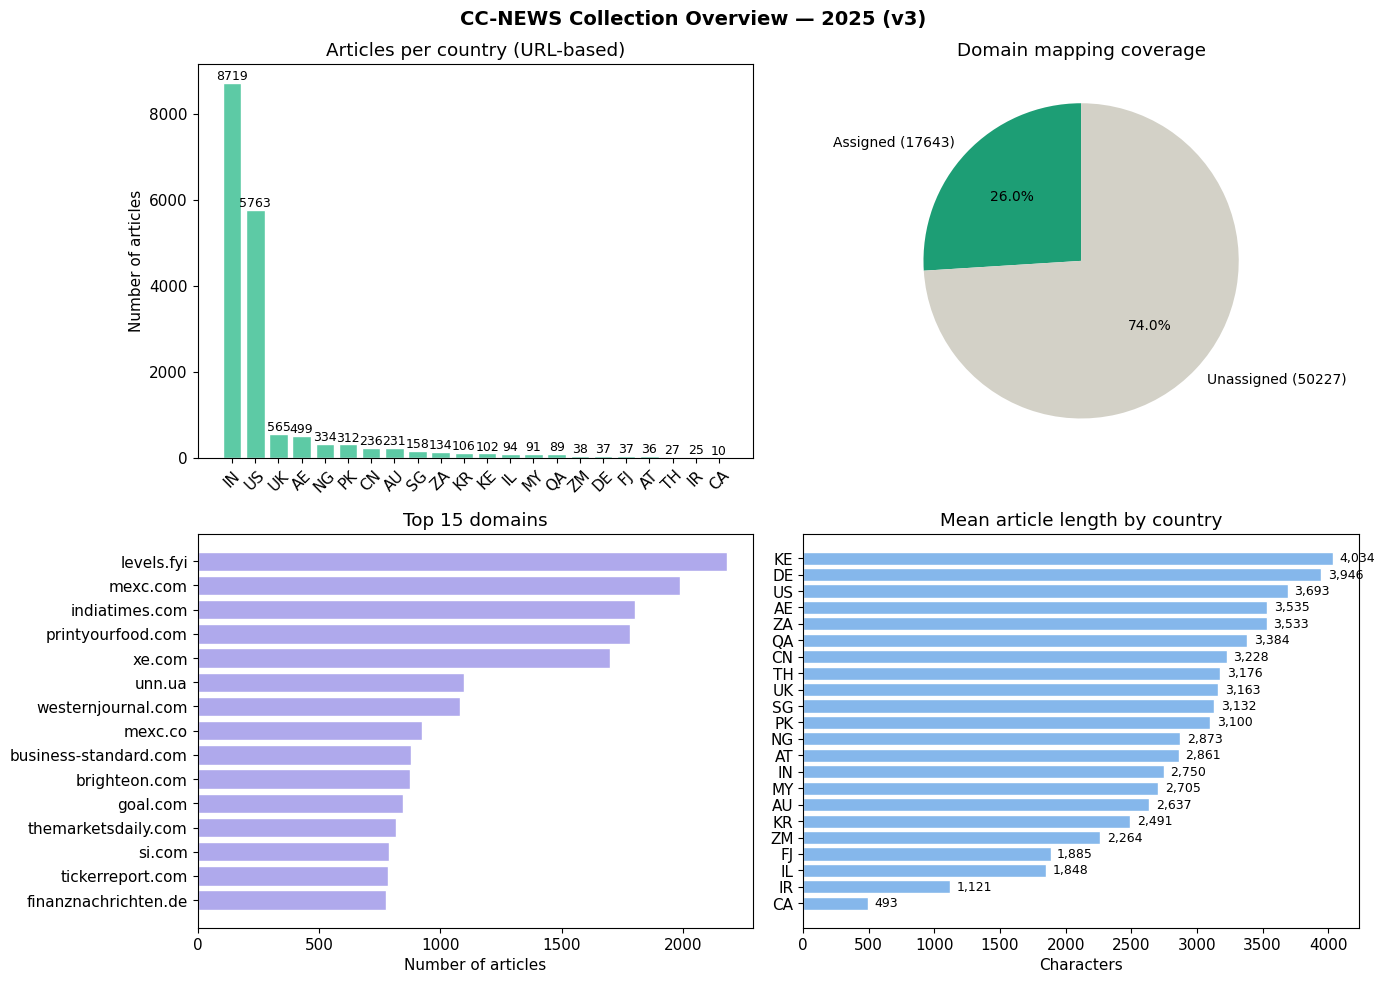

Figure saved to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/


In [21]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.facecolor': 'white'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'CC-NEWS Collection Overview — {TARGET_YEAR} ({DATA_VERSION})', fontsize=14, fontweight='bold')

# --- 1. Articles per country ---
ax = axes[0, 0]
country_counts = df['country_url'].value_counts()
bars = ax.bar(country_counts.index, country_counts.values, color='#5DCAA5', edgecolor='white')
ax.set_title('Articles per country (URL-based)')
ax.set_ylabel('Number of articles')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, country_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val),
            ha='center', va='bottom', fontsize=9)

# --- 2. Assigned vs unassigned ---
ax = axes[0, 1]
assigned = df['country_url'].notna().sum()
unassigned = df['country_url'].isna().sum()
ax.pie([assigned, unassigned],
       labels=[f'Assigned ({assigned})', f'Unassigned ({unassigned})'],
       colors=['#1D9E75', '#D3D1C7'], startangle=90,
       autopct='%1.1f%%', textprops={'fontsize': 10})
ax.set_title('Domain mapping coverage')

# --- 3. Top 15 domains ---
ax = axes[1, 0]
top_domains = df['registered_domain'].value_counts().head(15)
ax.barh(top_domains.index[::-1], top_domains.values[::-1], color='#AFA9EC', edgecolor='white')
ax.set_title('Top 15 domains')
ax.set_xlabel('Number of articles')

# --- 4. Mean article length by country ---
ax = axes[1, 1]
df['text_length'] = df['text'].str.len()
length_by_country = df.groupby('country_url')['text_length'].mean().sort_values(ascending=True)
bars = ax.barh(length_by_country.index, length_by_country.values, color='#85B7EB', edgecolor='white')
ax.set_title('Mean article length by country')
ax.set_xlabel('Characters')
for bar, val in zip(bars, length_by_country.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{DATA_PROCESSED}/collection_overview_{TARGET_YEAR}_{DATA_VERSION}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {DATA_PROCESSED}/')

---
## 5. Next Steps

**Data quality checks:**

- Review the list of unassigned domains. High-frequency domains from identifiable countries should be added to `DOMAIN_TO_COUNTRY` and the pipeline re-run (delete the country assignment checkpoint first).
- Assess country balance. If any country of interest has fewer than ~50 articles, increase `N_WARC_FILES` or add a second month of data.
- To add a second month, change `TARGET_YEAR` and `TARGET_MONTH` and re-run from Section 1. File names include the month, so existing checkpoints are not affected.

**Subsequent notebooks:**

- **Notebook 02 — NER + Geonames:** Extract geographic entities from article text using spaCy NER, then map them to standardised country codes using the Geonames.org database (Method 2 of 3).
- **Notebook 03 — Syntactic covariates:** Compute per-article metrics (average word length, sentence length, paragraph length) for use as regression controls.
- **Notebook 04 — Sentiment scoring:** Apply VADER and RoBERTa classifiers to all articles.